In [39]:
# Blood Cancer Detection using CNN

#This project uses a Convolutional Neural Network (CNN) to classify blood cell images as Benign or Malignant.

In [40]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [41]:
dataset_path="/content/dataset"

In [42]:
datagen=ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

In [43]:
train_data=datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=32,
    subset="training",
    class_mode="categorical"
)

val_data=datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=32,
    subset="validation",
    class_mode="categorical",
    shuffle=False
)

Found 4000 images belonging to 5 classes.
Found 1000 images belonging to 5 classes.


In [44]:
print(train_data.class_indices)

{'basophil': 0, 'erythroblast': 1, 'monocyte': 2, 'myeloblast': 3, 'seg_neutrophil': 4}


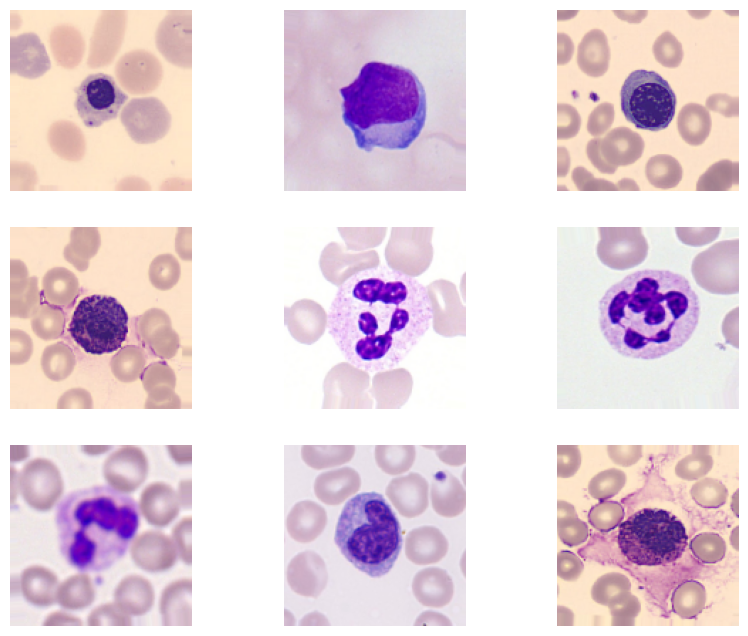

In [45]:
plt.figure(figsize=(10,8))

images,labels=next(train_data)

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.axis("off")

plt.show()

In [46]:
model=Sequential()

model.add(Conv2D(32,(3,3),activation="relu",input_shape=(128,128,3)))
model.add(MaxPooling2D())

model.add(Conv2D(64,(3,3),activation="relu"))
model.add(MaxPooling2D())

model.add(Conv2D(128,(3,3),activation="relu"))
model.add(MaxPooling2D())

model.add(Flatten())

model.add(Dense(256,activation="relu"))
model.add(Dropout(0.5))

model.add(Dense(5,activation="softmax"))

In [47]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,517,317 (24.86 MB)

 Trainable params: 6,517,317 (24.86 MB)

 Non-trainable params: 0 (0.00 B)

In [48]:
early_stop=EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [ ]:
history=model.fit(
    train_data,
    epochs=5,
    validation_data=val_data,
    callbacks=[early_stop]
)

Epoch 1/5


In [ ]:
loss,accuracy=model.evaluate(val_data)

print("Validation Accuracy :",round(accuracy*100,2),"%")

In [37]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Training","Validation"])

plt.show()

NameError: name 'history' is not defined

In [38]:
predictions=model.predict(val_data)

pred=np.argmax(predictions,axis=1)

print(pred[:20])

32/32 ━━━━━━━━━━━━━━━━━━━━ 18s 544ms/step
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [ ]:
model.save("Blood_Cancer_CNN.keras")

print("Model saved successfully.")

## Conclusion

A Convolutional Neural Network (CNN) was trained to classify blood cell images into five categories. The model learned image features effectively and achieved good validation accuracy, demonstrating that CNNs can be used for automated blood cell image classification.